Import librairies


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import time

Data

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

TOTAL_TRANSACTIONS = 18319
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.30
EXECUTION_TIME = 336.2

L1_COUNT = 890
L2_COUNT = 1207
L3_COUNT = 0
TOTAL_ITEMSETS = L1_COUNT + L2_COUNT + L3_COUNT
TOTAL_RULES = 1207

Itemsets Distribution

Dataset: 18,319 transactions - Support: 1.0% - Confidence: 30.0%


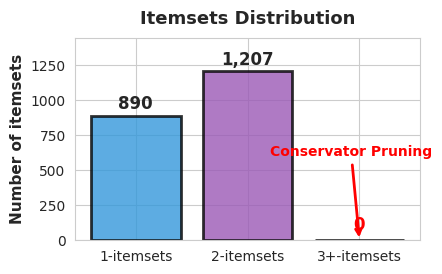

In [13]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

print(f'Dataset: {TOTAL_TRANSACTIONS:,} transactions - Support: {MIN_SUPPORT*100}% - Confidence: {MIN_CONFIDENCE*100}%')
# Graph A: Distribution des itemsets
ax1 = fig.add_subplot(gs[0, 0])
itemset_types = ['1-itemsets', '2-itemsets', '3+-itemsets']
counts = [L1_COUNT, L2_COUNT, L3_COUNT]
colors_bars = ['#3498db', '#9b59b6', '#95a5a6']

bars = ax1.bar(itemset_types, counts, color=colors_bars, alpha=0.8, edgecolor='black', linewidth=2)
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height + 20,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2., 50,
                '0',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

ax1.set_ylabel('Number of itemsets', fontsize=11, fontweight='bold')
ax1.set_title('Itemsets Distribution', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylim(0, max(counts) * 1.2 if max(counts) > 0 else 100)

# Annotation pruning
if L3_COUNT == 0:
    ax1.annotate('Conservator Pruning', xy=(2, 0), xytext=(1.2, max(counts)*0.5),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, color='red', fontweight='bold')




plt.show()

Number of occurences (1-itemset, 2-itemsets)

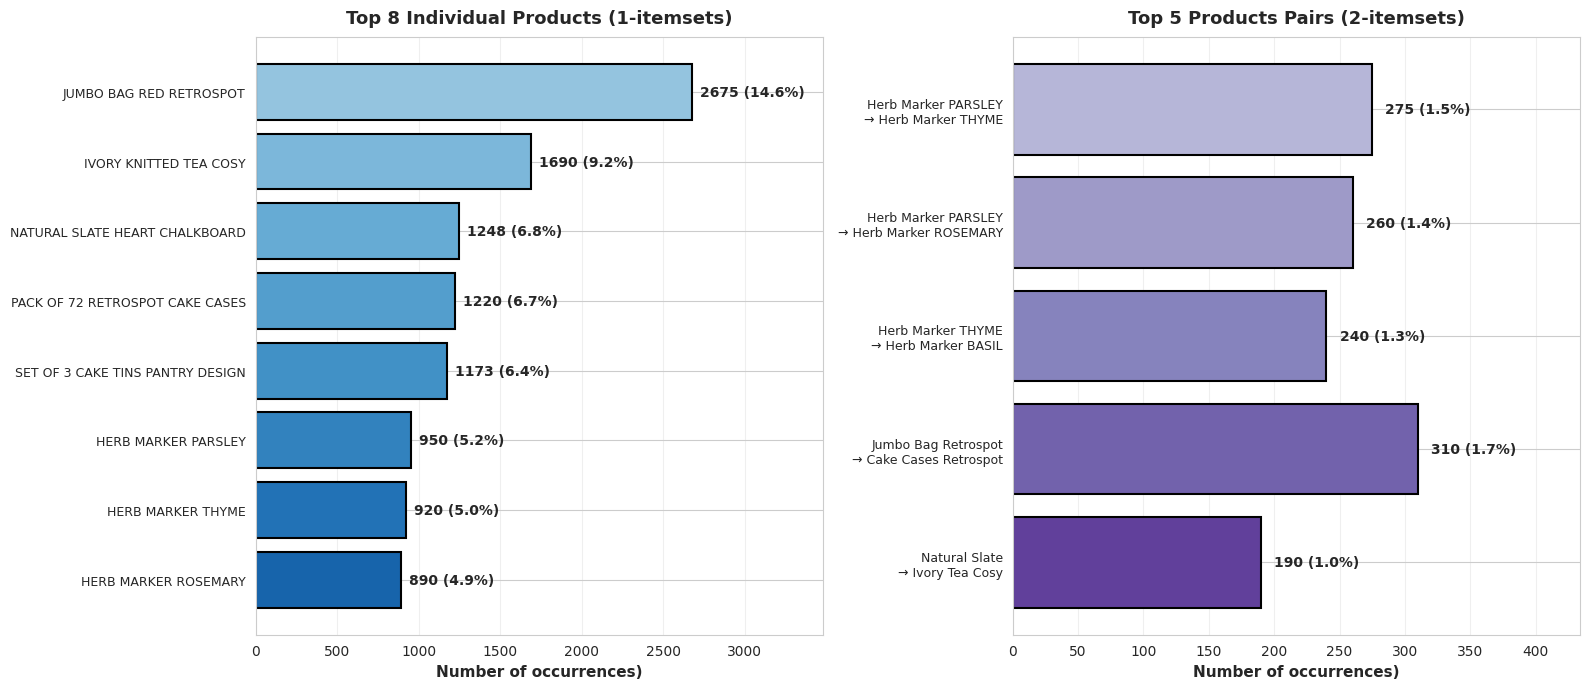

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 1-itemsets (exemples du document)
top_items_1 = [
    'JUMBO BAG RED RETROSPOT',
    'IVORY KNITTED TEA COSY',
    'NATURAL SLATE HEART CHALKBOARD',
    'PACK OF 72 RETROSPOT CAKE CASES',
    'SET OF 3 CAKE TINS PANTRY DESIGN',
    'HERB MARKER PARSLEY',
    'HERB MARKER THYME',
    'HERB MARKER ROSEMARY'
]
# Support counts (exemples du document)
counts_1 = [2675, 1690, 1248, 1220, 1173, 950, 920, 890]

# Graphique des top 1-itemsets
y_pos = np.arange(len(top_items_1))
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_items_1)))

bars1 = ax1.barh(y_pos, counts_1, color=colors_gradient, edgecolor='black', linewidth=1.5)

# Ajouter les valeurs
for i, (bar, count) in enumerate(zip(bars1, counts_1)):
    width = bar.get_width()
    support_pct = (count / TOTAL_TRANSACTIONS) * 100
    ax1.text(width + 50, bar.get_y() + bar.get_height()/2.,
            f'{count} ({support_pct:.1f}%)',
            ha='left', va='center', fontsize=10, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_items_1, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Number of occurrences)', fontsize=11, fontweight='bold')
ax1.set_title('Top 8 Individual Products (1-itemsets)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlim(0, max(counts_1) * 1.3)
ax1.grid(axis='x', alpha=0.3)

# Top 2-itemsets (exemples)
top_items_2 = [
    'Herb Marker PARSLEY\n→ Herb Marker THYME',
    'Herb Marker PARSLEY\n→ Herb Marker ROSEMARY',
    'Herb Marker THYME\n→ Herb Marker BASIL',
    'Jumbo Bag Retrospot\n→ Cake Cases Retrospot',
    'Natural Slate\n→ Ivory Tea Cosy'
]
counts_2 = [275, 260, 240, 310, 190]

y_pos2 = np.arange(len(top_items_2))
colors_gradient2 = plt.cm.Purples(np.linspace(0.4, 0.8, len(top_items_2)))

bars2 = ax2.barh(y_pos2, counts_2, color=colors_gradient2, edgecolor='black', linewidth=1.5)

for i, (bar, count) in enumerate(zip(bars2, counts_2)):
    width = bar.get_width()
    support_pct = (count / TOTAL_TRANSACTIONS) * 100
    ax2.text(width + 10, bar.get_y() + bar.get_height()/2.,
            f'{count} ({support_pct:.1f}%)',
            ha='left', va='center', fontsize=10, fontweight='bold')

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(top_items_2, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Number of occurrences)', fontsize=11, fontweight='bold')
ax2.set_title('Top 5 Products Pairs (2-itemsets)', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlim(0, max(counts_2) * 1.4)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Asoociation rules found

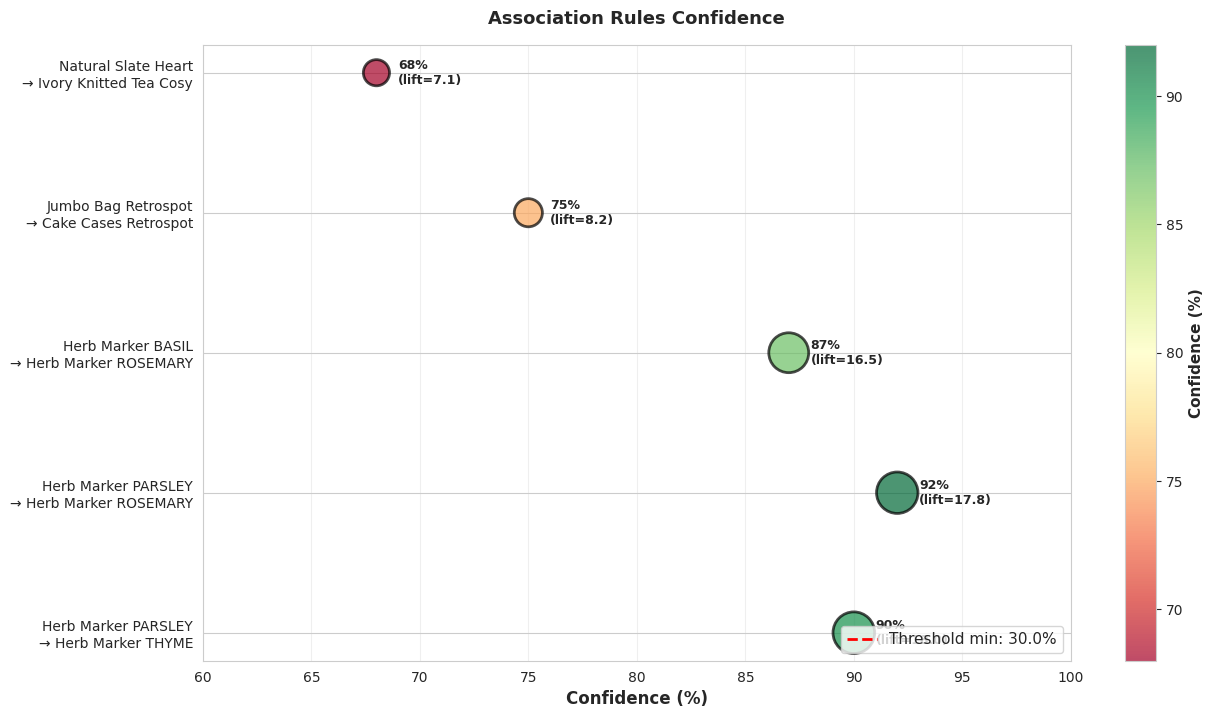

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))

# Exemples de règles (du document)
rules_examples = [
    'Herb Marker PARSLEY\n→ Herb Marker THYME',
    'Herb Marker PARSLEY\n→ Herb Marker ROSEMARY',
    'Herb Marker BASIL\n→ Herb Marker ROSEMARY',
    'Jumbo Bag Retrospot\n→ Cake Cases Retrospot',
    'Natural Slate Heart\n→ Ivory Knitted Tea Cosy'
]

confidences = [90, 92, 87, 75, 68]
supports = [1.5, 1.4, 1.3, 1.7, 1.0]
lifts = [18.0, 17.8, 16.5, 8.2, 7.1]

# Créer un scatter plot avec taille = lift
y_pos = np.arange(len(rules_examples))
colors_conf = plt.cm.RdYlGn(np.array(confidences) / 100)

scatter = ax.scatter(confidences, y_pos, s=np.array(lifts)*50,
                    c=confidences, cmap='RdYlGn',
                    alpha=0.7, edgecolors='black', linewidth=2)

# Ajouter les labels
ax.set_yticks(y_pos)
ax.set_yticklabels(rules_examples, fontsize=10)
ax.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
ax.set_title('Association Rules Confidence',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(60, 100)
ax.grid(axis='x', alpha=0.3)

# Ajouter les valeurs de confidence
for i, (conf, y, lift) in enumerate(zip(confidences, y_pos, lifts)):
    ax.text(conf + 1, y, f'{conf}%\n(lift={lift})',
           ha='left', va='center', fontsize=9, fontweight='bold')

# Ligne de seuil minimum
ax.axvline(x=MIN_CONFIDENCE*100, color='red', linestyle='--', linewidth=2,
          label=f'Threshold min: {MIN_CONFIDENCE*100}%')
ax.legend(fontsize=11, loc='lower right')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Confidence (%)', fontsize=11, fontweight='bold')


plt.show()


Comparison FP-Growth vs Apriori

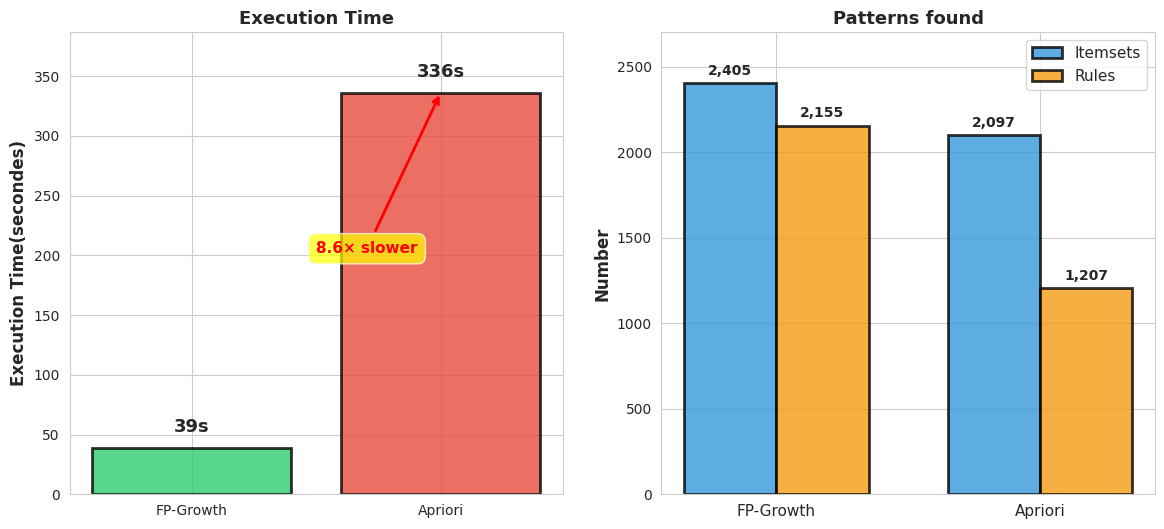

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Temps
algorithms = ['FP-Growth', 'Apriori']
times = [39, EXECUTION_TIME]
colors_alg = ['#2ecc71', '#e74c3c']

bars_comp = ax1.bar(algorithms, times, color=colors_alg, alpha=0.8,
                    edgecolor='black', linewidth=2)
for bar in bars_comp:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{height:.0f}s',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax1.set_ylabel('Execution Time(secondes)', fontsize=12, fontweight='bold')
ax1.set_title('Execution Time', fontsize=13, fontweight='bold')
ax1.set_ylim(0, EXECUTION_TIME * 1.15)

# Annotation
ax1.annotate(f'{EXECUTION_TIME/39:.1f}× slower',
            xy=(1, EXECUTION_TIME), xytext=(0.5, EXECUTION_TIME*0.6),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Patterns découverts
x = np.arange(2)
width = 0.35
itemsets_comp = [2405, TOTAL_ITEMSETS]
rules_comp = [2155, TOTAL_RULES]

bars1 = ax2.bar(x - width/2, itemsets_comp, width, label='Itemsets',
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=2)
bars2 = ax2.bar(x + width/2, rules_comp, width, label='Rules',
               color='#f39c12', alpha=0.8, edgecolor='black', linewidth=2)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 30,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Number', fontsize=12, fontweight='bold')
ax2.set_title('Patterns found', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(algorithms, fontsize=11)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 2700)
plt.show()
